# # Muon Gamma Generator Validation
# 
# **Tests:**
# 1. Event-ID ↔ muon_id ändern sich bidirektional synchron
# 2. Gamma-Konsistenz pro (muon_id, nc_id): #Einträge = #unique gamma_ids = max+1
# 3. Vertices-Konsistenz: DebugVertices vs. Geant4 vertices pro Event
# 4. Vollständigkeit: Alle event_ids vorhanden, alle muon_ids eindeutig

In [1]:
import h5py
import numpy as np
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
import glob
import os

In [2]:
# === Configuration ===
HDF5_DIR = "/global/cfs/projectdirs/legend/users/tbuerger/sim/RMGApplications/02-NCGammaGun/build/"  # Your HDF5 file path

# %%
# === Load Data ===
print("📂 Loading HDF5 data from multiple files...")

# Find all matching files
hdf5_files = sorted(glob.glob(os.path.join(HDF5_DIR, "output_t*.hdf5")))
if len(hdf5_files) == 0:
    raise FileNotFoundError(f"No output_t*.hdf5 files found in {HDF5_DIR}")

print(f"Found {len(hdf5_files)} files to process")

# Initialize lists to collect data
all_debug_event_id = []
all_debug_muon_id = []
all_debug_nc_id = []
all_debug_gamma_id = []
all_vertices_event_id = []
all_vertices_n_part = []

# Load from all files
for i, filepath in enumerate(hdf5_files):
    print(f"  Loading file {i+1}/{len(hdf5_files)}: {os.path.basename(filepath)}")
    
    with h5py.File(filepath, 'r') as f:
        # Load DebugVertices
        all_debug_event_id.append(f['//hit/DebugVertices/event_id/pages'][:])
        all_debug_muon_id.append(f['//hit/DebugVertices/muon_id/pages'][:])
        all_debug_nc_id.append(f['//hit/DebugVertices/nc_id/pages'][:])
        all_debug_gamma_id.append(f['//hit/DebugVertices/gamma_id/pages'][:])
        
        # Load Geant4 vertices
        all_vertices_event_id.append(f['//hit/vertices/evtid/pages'][:])
        all_vertices_n_part.append(f['//hit/vertices/n_part/pages'][:])

# Concatenate all arrays
debug_event_id = np.concatenate(all_debug_event_id)
debug_muon_id = np.concatenate(all_debug_muon_id)
debug_nc_id = np.concatenate(all_debug_nc_id)
debug_gamma_id = np.concatenate(all_debug_gamma_id)
vertices_event_id = np.concatenate(all_vertices_event_id)
vertices_n_part = np.concatenate(all_vertices_n_part)

# Create DataFrames
df_debug = pd.DataFrame({
    'event_id': debug_event_id,
    'muon_id': debug_muon_id,
    'nc_id': debug_nc_id,
    'gamma_id': debug_gamma_id
})

df_vertices = pd.DataFrame({
    'event_id': vertices_event_id,
    'n_part': vertices_n_part
})

print(f"✅ Loaded {len(df_debug)} DebugVertices entries")
print(f"✅ Loaded {len(df_vertices)} Geant4 vertices entries")
print()

📂 Loading HDF5 data from multiple files...
Found 256 files to process
  Loading file 1/256: output_t0.hdf5
  Loading file 2/256: output_t1.hdf5
  Loading file 3/256: output_t10.hdf5
  Loading file 4/256: output_t100.hdf5
  Loading file 5/256: output_t101.hdf5
  Loading file 6/256: output_t102.hdf5
  Loading file 7/256: output_t103.hdf5
  Loading file 8/256: output_t104.hdf5
  Loading file 9/256: output_t105.hdf5
  Loading file 10/256: output_t106.hdf5
  Loading file 11/256: output_t107.hdf5
  Loading file 12/256: output_t108.hdf5
  Loading file 13/256: output_t109.hdf5
  Loading file 14/256: output_t11.hdf5
  Loading file 15/256: output_t110.hdf5
  Loading file 16/256: output_t111.hdf5
  Loading file 17/256: output_t112.hdf5
  Loading file 18/256: output_t113.hdf5
  Loading file 19/256: output_t114.hdf5
  Loading file 20/256: output_t115.hdf5
  Loading file 21/256: output_t116.hdf5
  Loading file 22/256: output_t117.hdf5
  Loading file 23/256: output_t118.hdf5
  Loading file 24/256: ou

In [3]:
# === TEST 1: Event-ID ↔ muon_id Bidirektionale Synchronisation ===
print("=" * 70)
print("TEST 1: Event-ID ↔ muon_id Bidirektionale Synchronisation")
print("=" * 70)

# Check: Event-ID wechselt ↔ muon_id wechselt
df_debug['muon_id_changed'] = df_debug['muon_id'] != df_debug['muon_id'].shift(1)
df_debug['event_id_changed'] = df_debug['event_id'] != df_debug['event_id'].shift(1)

# Erste Zeile immer True (kein Vergleich möglich)
df_debug.loc[0, 'muon_id_changed'] = True
df_debug.loc[0, 'event_id_changed'] = True

# Bidirektionaler Check
violations_muon_but_not_event = df_debug[
    df_debug['muon_id_changed'] & ~df_debug['event_id_changed']
]
violations_event_but_not_muon = df_debug[
    df_debug['event_id_changed'] & ~df_debug['muon_id_changed']
]

test1_passed = len(violations_muon_but_not_event) == 0 and len(violations_event_but_not_muon) == 0

if test1_passed:
    print("✅ PASSED: Event-ID und muon_id ändern sich synchron")
else:
    print("❌ FAILED: Inkonsistente Änderungen gefunden!")
    if len(violations_muon_but_not_event) > 0:
        print(f"   muon_id wechselt, aber Event-ID nicht: {len(violations_muon_but_not_event)} Fälle")
        print(violations_muon_but_not_event[['event_id', 'muon_id', 'nc_id', 'gamma_id']].head())
    if len(violations_event_but_not_muon) > 0:
        print(f"   Event-ID wechselt, aber muon_id nicht: {len(violations_event_but_not_muon)} Fälle")
        print(violations_event_but_not_muon[['event_id', 'muon_id', 'nc_id', 'gamma_id']].head())

print()

TEST 1: Event-ID ↔ muon_id Bidirektionale Synchronisation
✅ PASSED: Event-ID und muon_id ändern sich synchron



In [4]:
# === TEST 2: Gamma-Konsistenz pro (muon_id, nc_id) ===
print("=" * 70)
print("TEST 2: Gamma-Konsistenz pro NC (#Einträge = #unique gamma_ids = max+1)")
print("=" * 70)

gamma_stats = df_debug.groupby(['muon_id', 'nc_id'])['gamma_id'].agg([
    ('n_entries', 'size'),
    ('n_unique', 'nunique'),
    ('max_id', 'max'),
    ('min_id', 'min')
])
gamma_stats['max_plus_1'] = gamma_stats['max_id'] + 1

# Test A: n_entries == n_unique
test2a_violations = gamma_stats[gamma_stats['n_entries'] != gamma_stats['n_unique']]

# Test B: n_entries == max+1
test2b_violations = gamma_stats[gamma_stats['n_entries'] != gamma_stats['max_plus_1']]

# Test C: min_id == 0 (gamma_ids starten bei 0)
test2c_violations = gamma_stats[gamma_stats['min_id'] != 0]

test2_passed = (len(test2a_violations) == 0 and 
                len(test2b_violations) == 0 and 
                len(test2c_violations) == 0)

if test2_passed:
    print("✅ PASSED: Alle NCs haben konsistente gamma_ids [0..N-1]")
    print(f"   Mean gammas/NC: {gamma_stats['n_entries'].mean():.2f}")
    print(f"   Min: {gamma_stats['n_entries'].min()}, Max: {gamma_stats['n_entries'].max()}")
else:
    print("❌ FAILED: Inkonsistente gamma_ids gefunden!")
    if len(test2a_violations) > 0:
        print(f"   Duplikate oder fehlende gamma_ids: {len(test2a_violations)} NCs")
        print(test2a_violations.head())
    if len(test2b_violations) > 0:
        print(f"   max(gamma_id)+1 ≠ Anzahl: {len(test2b_violations)} NCs")
        print(test2b_violations.head())
    if len(test2c_violations) > 0:
        print(f"   gamma_id startet nicht bei 0: {len(test2c_violations)} NCs")
        print(test2c_violations.head())

print()

TEST 2: Gamma-Konsistenz pro NC (#Einträge = #unique gamma_ids = max+1)
✅ PASSED: Alle NCs haben konsistente gamma_ids [0..N-1]
   Mean gammas/NC: 1.46
   Min: 1, Max: 8



In [5]:
# === TEST 3: DebugVertices vs. Geant4 vertices ===
print("=" * 70)
print("TEST 3: DebugVertices ↔ Geant4 vertices Konsistenz")
print("=" * 70)

# Count entries per event_id in both datasets
debug_counts = df_debug.groupby('event_id').size().reset_index(name='debug_count')
vertices_counts = df_vertices.groupby('event_id').size().reset_index(name='vertices_count')

# Merge
comparison = pd.merge(debug_counts, vertices_counts, on='event_id', how='outer')
comparison.fillna(0, inplace=True)
comparison = comparison.astype({'debug_count': int, 'vertices_count': int})

# Check mismatches
mismatches = comparison[comparison['debug_count'] != comparison['vertices_count']]

test3_passed = len(mismatches) == 0

if test3_passed:
    print("✅ PASSED: DebugVertices und Geant4 vertices haben gleiche Anzahl pro Event")
else:
    print("❌ FAILED: Unterschiedliche Anzahl gefunden!")
    print(f"   {len(mismatches)} Events mit Diskrepanz:")
    print(mismatches.head(10))

print()

TEST 3: DebugVertices ↔ Geant4 vertices Konsistenz
✅ PASSED: DebugVertices und Geant4 vertices haben gleiche Anzahl pro Event



In [6]:
# === TEST 4: Vollständigkeit ===
print("=" * 70)
print("TEST 4: Vollständigkeit (alle event_ids vorhanden, muon_ids eindeutig)")
print("=" * 70)

# Expected event_ids: [0..max_event_id]
max_event_id = df_debug['event_id'].max()
expected_events = set(range(max_event_id + 1))
actual_events = set(df_debug['event_id'].unique())

missing_events = expected_events - actual_events
extra_events = actual_events - expected_events

# Check: Each event_id has exactly one muon_id
event_muon_map = df_debug.groupby('event_id')['muon_id'].nunique()
multi_muon_events = event_muon_map[event_muon_map > 1]

# Check: Each muon_id appears in exactly one event_id
muon_event_map = df_debug.groupby('muon_id')['event_id'].nunique()
multi_event_muons = muon_event_map[muon_event_map > 1]

test4_passed = (len(missing_events) == 0 and 
                len(extra_events) == 0 and 
                len(multi_muon_events) == 0 and 
                len(multi_event_muons) == 0)

if test4_passed:
    print(f"✅ PASSED: Alle event_ids [0..{max_event_id}] vorhanden")
    print(f"✅ PASSED: Jede event_id hat genau eine muon_id")
    print(f"✅ PASSED: Jede muon_id erscheint in genau einer event_id")
else:
    print("❌ FAILED: Vollständigkeitsprobleme gefunden!")
    if missing_events:
        print(f"   Fehlende event_ids: {sorted(missing_events)[:10]}{'...' if len(missing_events) > 10 else ''}")
    if extra_events:
        print(f"   Zusätzliche event_ids: {sorted(extra_events)[:10]}{'...' if len(extra_events) > 10 else ''}")
    if len(multi_muon_events) > 0:
        print(f"   Events mit mehreren muon_ids: {len(multi_muon_events)}")
        print(multi_muon_events.head())
    if len(multi_event_muons) > 0:
        print(f"   Muons in mehreren Events: {len(multi_event_muons)}")
        print(multi_event_muons.head())

print()

TEST 4: Vollständigkeit (alle event_ids vorhanden, muon_ids eindeutig)
✅ PASSED: Alle event_ids [0..999] vorhanden
✅ PASSED: Jede event_id hat genau eine muon_id
✅ PASSED: Jede muon_id erscheint in genau einer event_id



📊 FINAL SUMMARY
✅ PASS: Event-ID ↔ muon_id Sync
✅ PASS: Gamma-ID Konsistenz pro NC
✅ PASS: DebugVertices ↔ Geant4 vertices
✅ PASS: Vollständigkeit & Eindeutigkeit

🎉 ALL TESTS PASSED! Muon event structure is consistent.

📈 Generating plots...


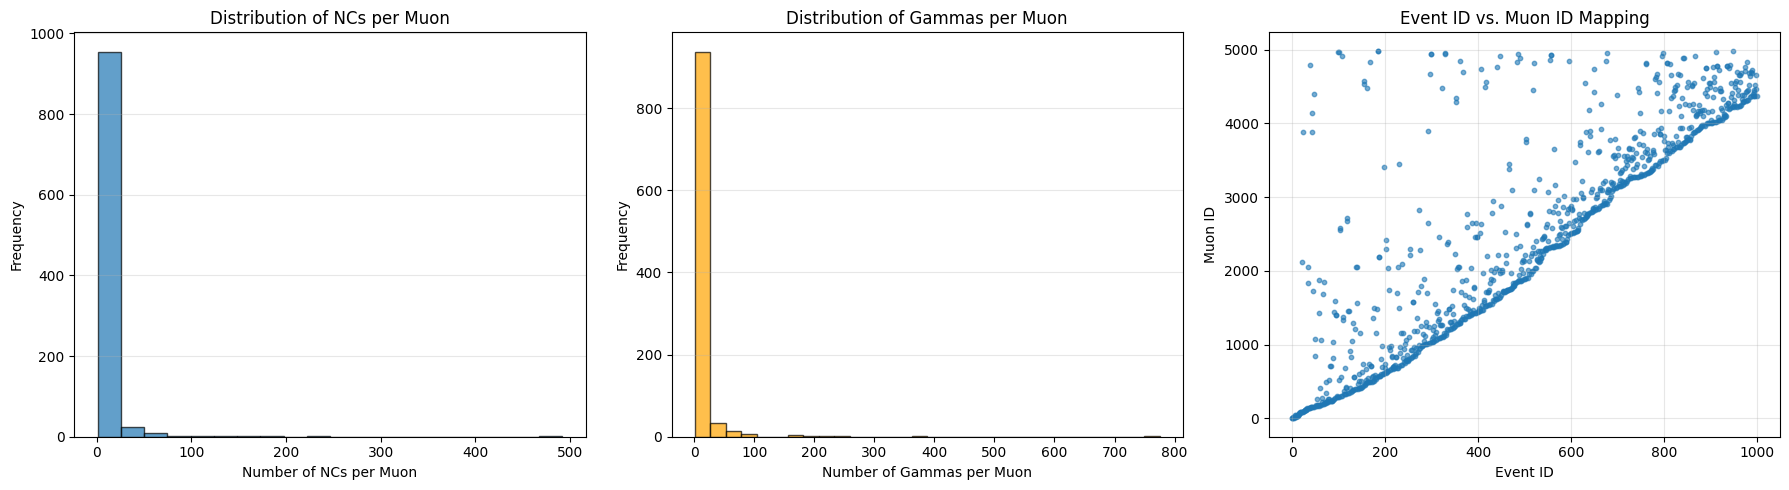

✅ Plots generated

📊 DETAILED STATISTICS

📌 Dataset Overview:
   Total events: 1000
   Total vertices (DebugVertices): 8913
   Total vertices (Geant4): 8913
   Unique muon_ids: 1000
   Unique nc_ids: 5588
   Unique (muon_id, nc_id) pairs: 6124
   Total DebugVertices entries: 8913
   Total Geant4 vertices entries: 8913

📌 NCs per Muon:
   Mean: 6.12
   Std:  22.88
   Min:  1
   Max:  492

📌 Gammas per Muon:
   Mean: 8.91
   Std:  34.47
   Min:  1
   Max:  775

📌 Gammas per NC:
   Mean: 1.46
   Std:  0.94
   Min:  1
   Max:  8

✅ Debug script completed


In [7]:
# === SUMMARY ===
print("=" * 70)
print("📊 FINAL SUMMARY")
print("=" * 70)

all_passed = test1_passed and test2_passed and test3_passed and test4_passed

tests = [
    ("Event-ID ↔ muon_id Sync", test1_passed),
    ("Gamma-ID Konsistenz pro NC", test2_passed),
    ("DebugVertices ↔ Geant4 vertices", test3_passed),
    ("Vollständigkeit & Eindeutigkeit", test4_passed)
]

for name, passed in tests:
    status = "✅ PASS" if passed else "❌ FAIL"
    print(f"{status}: {name}")

print()
if all_passed:
    print("🎉 ALL TESTS PASSED! Muon event structure is consistent.")
else:
    print("⚠️  SOME TESTS FAILED! Review output above.")

# %%
# === VISUALIZATION: Gammas & NCs per Muon ===
print("\n📈 Generating plots...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: NCs per Muon
ncs_per_muon = df_debug.groupby('muon_id')['nc_id'].nunique()
axes[0].hist(ncs_per_muon, bins=20, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of NCs per Muon')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of NCs per Muon')
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Gammas per Muon
gammas_per_muon = df_debug.groupby('muon_id').size()
axes[1].hist(gammas_per_muon, bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Number of Gammas per Muon')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Gammas per Muon')
axes[1].grid(axis='y', alpha=0.3)

# Plot 3: Event-ID vs. Muon-ID (should be 1:1)
event_muon_map = df_debug.groupby('event_id')['muon_id'].first().reset_index()
axes[2].scatter(event_muon_map['event_id'], event_muon_map['muon_id'], s=10, alpha=0.6)
axes[2].set_xlabel('Event ID')
axes[2].set_ylabel('Muon ID')
axes[2].set_title('Event ID vs. Muon ID Mapping')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Plots generated")

# %%
# === STATISTICS OUTPUT ===
print("\n" + "=" * 70)
print("📊 DETAILED STATISTICS")
print("=" * 70)

print(f"\n📌 Dataset Overview:")
print(f"   Total events: {df_debug['event_id'].nunique()}")
print(f"   Total vertices (DebugVertices): {len(df_debug)}")
print(f"   Total vertices (Geant4): {len(df_vertices)}")
print(f"   Unique muon_ids: {df_debug['muon_id'].nunique()}")
print(f"   Unique nc_ids: {df_debug['nc_id'].nunique()}")
print(f"   Unique (muon_id, nc_id) pairs: {df_debug[['muon_id', 'nc_id']].drop_duplicates().shape[0]}")
print(f"   Total DebugVertices entries: {len(df_debug)}")
print(f"   Total Geant4 vertices entries: {len(df_vertices)}")

print(f"\n📌 NCs per Muon:")
ncs_per_muon = df_debug.groupby('muon_id')['nc_id'].nunique()
print(f"   Mean: {ncs_per_muon.mean():.2f}")
print(f"   Std:  {ncs_per_muon.std():.2f}")
print(f"   Min:  {ncs_per_muon.min()}")
print(f"   Max:  {ncs_per_muon.max()}")

print(f"\n📌 Gammas per Muon:")
gammas_per_muon = df_debug.groupby('muon_id').size()
print(f"   Mean: {gammas_per_muon.mean():.2f}")
print(f"   Std:  {gammas_per_muon.std():.2f}")
print(f"   Min:  {gammas_per_muon.min()}")
print(f"   Max:  {gammas_per_muon.max()}")

print(f"\n📌 Gammas per NC:")
gammas_per_nc = gamma_stats['n_entries']
print(f"   Mean: {gammas_per_nc.mean():.2f}")
print(f"   Std:  {gammas_per_nc.std():.2f}")
print(f"   Min:  {gammas_per_nc.min()}")
print(f"   Max:  {gammas_per_nc.max()}")

print("\n✅ Debug script completed")